#OBJETIVOS

*El dataset posee la informacion de los partidos de la NFL dentro del perioso 2002-2025, con estso datos se realizaran analisis estadisticos para ver victorias, equipos top en victorias tanto en casa como visitante, promedios de puntos por cada temporada y un seguimiento de equipo por año y comparaciones entre algunos de ellos.

*De los equipos a nivel general mas consistentes destacan los patriots con mayor cantidad de victorias generales, mientras que otros como Raiders y Browns se mantienen en los puestos mas bajos

*El equipo con mas victorias dentro de este lapso son los Patriots y el que esta mas bajo son los Browns

*Se destaca tambien que hay años en los que las ofensivas se mantienen muy activas, el año que 2020 tiene el promedio de 49 puntos por partido, mientras que el año con menor cantidad es 2005 con un promedio de 41 puntos por partido, estos son puntos entre ambos equipos.


In [15]:
#Importacion de librerias

import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime


In [16]:
#Carga de dataframe

df = pd.read_csv("nfl_team_stats_2002-2025.csv")

In [17]:
#Verificacion de datos

print(df.head())

   season week        date  time_et  neutral       away        home  \
0    2002    1  2002-09-05  8:30 PM    False      49ers      Giants   
1    2002    1  2002-09-08  1:00 PM    False      Colts     Jaguars   
2    2002    1  2002-09-08  1:00 PM    False  Cardinals  Commanders   
3    2002    1  2002-09-08  1:00 PM    False      Lions    Dolphins   
4    2002    1  2002-09-08  1:00 PM    False     Eagles      Titans   

   score_away  score_home  first_downs_away  ...  redzone_comp_home  \
0          16          13                13  ...                  0   
1          28          25                18  ...                  0   
2          23          31                14  ...                  0   
3          21          49                15  ...                  0   
4          24          27                17  ...                  0   

   redzone_att_home  fumbles_away  fumbles_home  interceptions_away  \
0                 6             0             0                   1   
1   

In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   season                         6499 non-null   int64
 1   week                           6499 non-null   str  
 2   date                           6499 non-null   str  
 3   time_et                        6499 non-null   str  
 4   neutral                        6499 non-null   bool 
 5   away                           6499 non-null   str  
 6   home                           6499 non-null   str  
 7   score_away                     6499 non-null   int64
 8   score_home                     6499 non-null   int64
 9   first_downs_away               6499 non-null   int64
 10  first_downs_home               6499 non-null   int64
 11  first_downs_from_passing_away  6499 non-null   int64
 12  first_downs_from_passing_home  6499 non-null   int64
 13  first_downs_from_rushing_away

In [19]:
# Estandarizar nombres de columnas

df.columns = df.columns.str.lower()
df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)
df['date'] = pd.to_datetime(df['date'])

In [20]:
#Validacion de datos

print(df['home'].unique())

<StringArray>
[    'Giants',    'Jaguars', 'Commanders',   'Dolphins',     'Titans',
   'Panthers',     'Browns',    'Bengals',      'Bears',      'Bills',
    'Packers',    'Broncos',    'Raiders', 'Buccaneers',     'Texans',
   'Patriots',     'Saints',     'Ravens',     'Chiefs',       'Jets',
    'Cowboys',    'Falcons',      'Colts',       'Rams',   'Seahawks',
    'Vikings',   'Chargers',      '49ers',   'Steelers',     'Eagles',
  'Cardinals',      'Lions']
Length: 32, dtype: str


In [21]:
df['date'].info()

<class 'pandas.Series'>
RangeIndex: 6499 entries, 0 to 6498
Series name: date
Non-Null Count  Dtype         
--------------  -----         
6499 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 50.9 KB


In [22]:
#Sumar puntos anotados por partido como visitante y local

df['points_scored'] = df['score_home'] + df['score_away']
points_trend = df.groupby('season')['points_scored'].mean()

print(points_trend)

season
2002    43.659176
2003    41.790262
2004    43.146067
2005    41.101124
2006    41.513109
2007    43.385768
2008    44.026217
2009    43.161049
2010    44.318352
2011    44.490637
2012    45.775281
2013    46.868914
2014    45.269663
2015    45.464419
2016    45.737828
2017    43.629213
2018    46.550562
2019    45.704120
2020    49.490706
2021    46.066667
2022    44.031690
2023    43.800000
2024    46.017544
2025    45.957895
Name: points_scored, dtype: float64


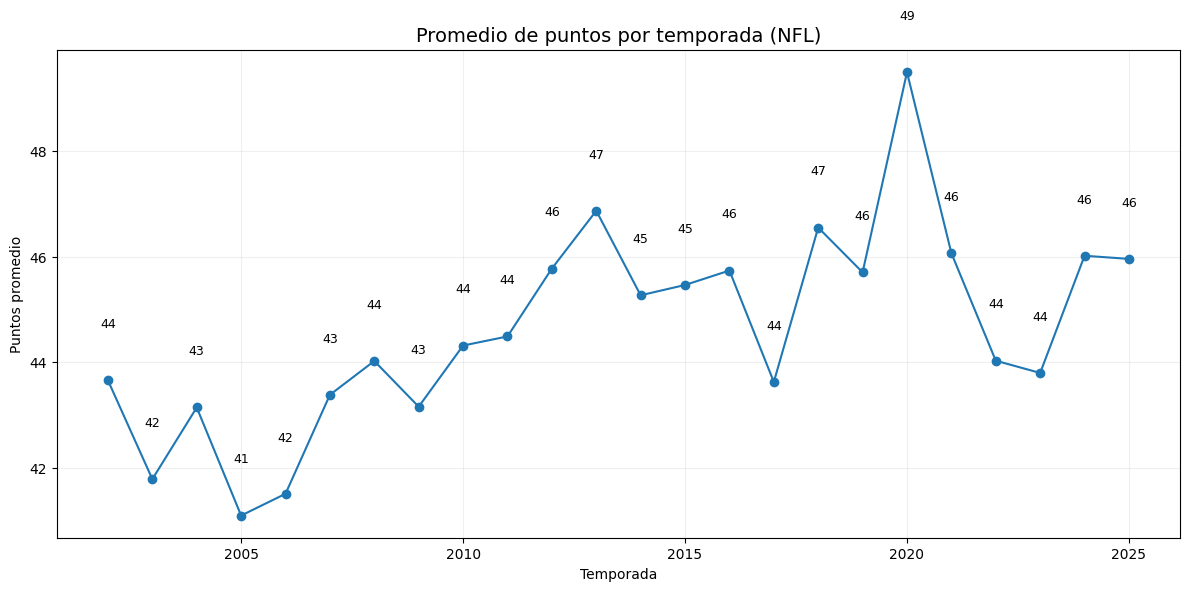

In [23]:
#Grafica de tendencia de puntos por temporada

plt.figure(figsize=(12,6))
plt.plot(points_trend.index, points_trend.values, marker='o')

for x, y in zip(points_trend.index, points_trend.values):
    plt.text(x, y+1, f"{y:.0f}", ha='center', fontsize=9)

plt.title("Promedio de puntos por temporada (NFL)", fontsize=14)
plt.xlabel("Temporada")
plt.ylabel("Puntos promedio")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#La grafica muestra la tendencia de las ofensivas de los equipos entre 2002 hasta la temporada 2025, aqui es visible que la temporada 2020 fue una temporada con un promedio de puntos muy alto (cerca de 49 por partido), el mas bajo fue en 2005 con cerca de 41. Todos los resultados mostrados en la grafica estan redondeados. 

In [24]:
#Creacion de columnas de equipos ganadores de local y visitante

df['home_win'] = (df['score_home'] > df['score_away']).astype(int)
df['away_win'] = (df['score_away'] > df['score_home']).astype(int)

In [25]:
#Renombrar columnas de equipos para mayor claridad

home_df = df[['season', 'home', 'home_win']].rename(columns={
    'home': 'team',
    'home_win': 'win'
})

away_df = df[['season', 'away', 'away_win']].rename(columns={
    'away': 'team',
    'away_win': 'win'
})

# Unir ambos
teams_df = pd.concat([home_df, away_df])

In [26]:
#Top 10 equipos con mas victorias general

top_teams = teams_df.groupby('team')['win'].sum() \
                   .sort_values(ascending=False) \
                   .head(10)

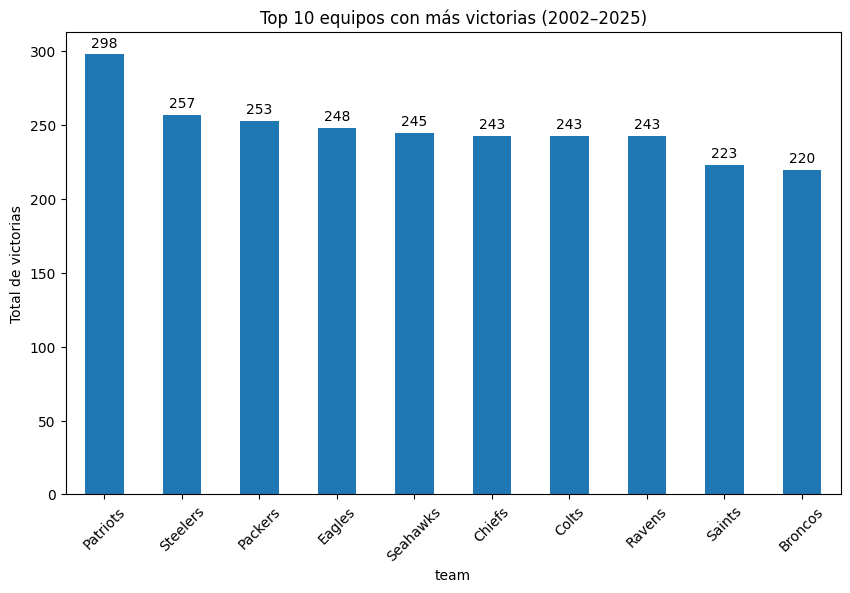

In [27]:
#Graficar el Top 10 equipos con mas victorias general

plt.figure(figsize=(10,6))
ax = top_teams.plot(kind='bar')

plt.title("Top 10 equipos con más victorias (2002–2025)")
plt.ylabel("Total de victorias")
plt.xticks(rotation=45)

# Agregar etiquetas con los valores en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

#El equipo con mas victorias en este lapso son los Patriots, gran parte de este resultado bien puede ser por que dentro del año 2000-2019 estuvo la temporada de Tom Brady, QB que le dio muchas victorias y superbowl a los Patriots

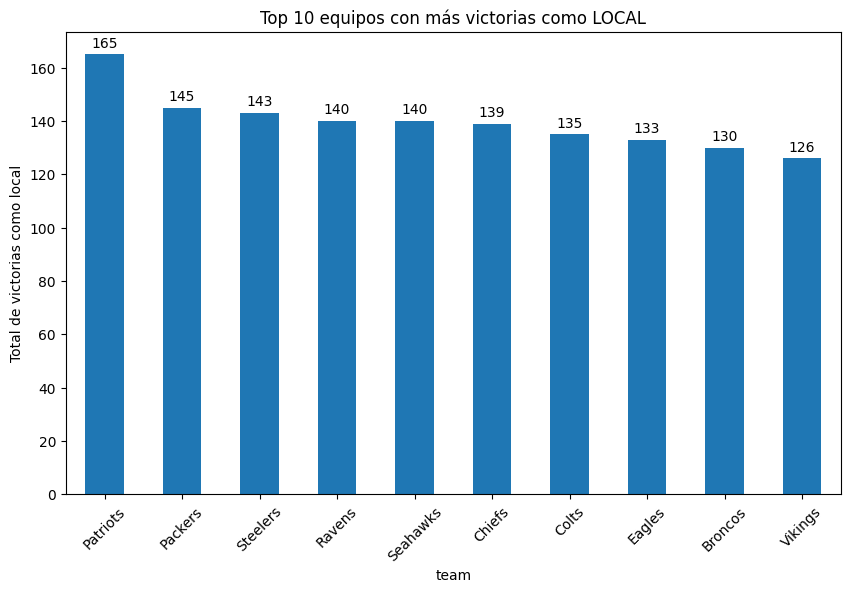

In [28]:
#Grafica de victorias como local

home_wins = home_df.groupby('team')['win'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
ho = home_wins.plot(kind='bar')

plt.title("Top 10 equipos con más victorias como LOCAL")
plt.ylabel("Total de victorias como local")
plt.xticks(rotation=45)

# Agregar etiquetas con los valores en cada barra
for container in ho.containers:
    ho.bar_label(container, fmt='%d', padding=3)


plt.show()

#De la misma manera que el anterior, el que tiene mas victorias son los Patriots, pero destaca que los Packers que en escala globalson el tercer equipo con mas victorias aqui son el segundo, ya que de 253 victorias totales poseen 145 de ellas como local en Lambeau Field, igual destaca que entran equipos que en top global no estan como Vikings

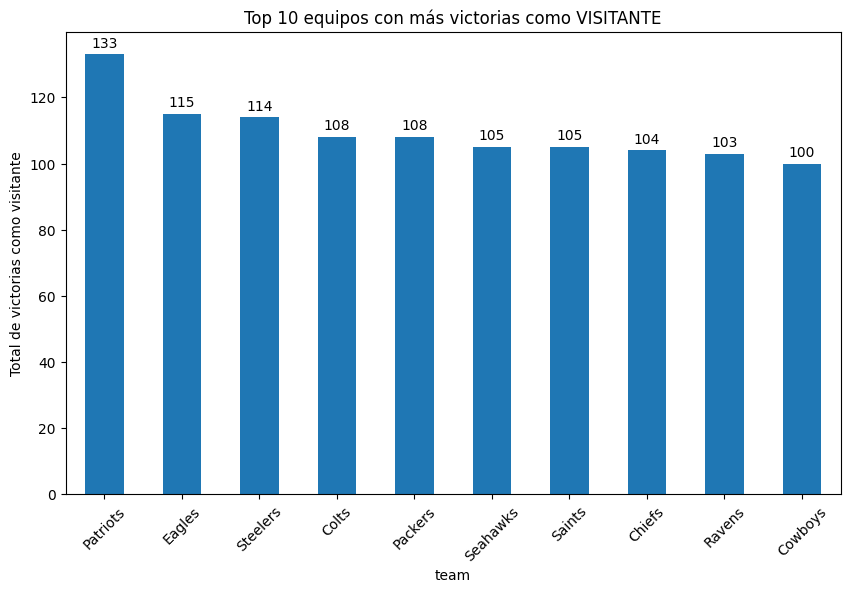

In [29]:
#Graficar los 10 equipos con más victorias como visitante

away_wins = away_df.groupby('team')['win'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
aw = away_wins.plot(kind='bar')

plt.title("Top 10 equipos con más victorias como VISITANTE")
plt.ylabel("Total de victorias como visitante")
plt.xticks(rotation=45)

# Agregar etiquetas con los valores en cada barra
for container in aw.containers:
    aw.bar_label(container, fmt='%d', padding=3)

plt.show()

#Los Patriots siguen encabezando, pero aqui el segundo lugar son los Eagles con 115 victorias del total de 248 que tienen en total, enseguida estan los Steelers con 114 de 257 que tienen en total. Otro de los que entran aqui y no estaban en el top generak son los Cowboys

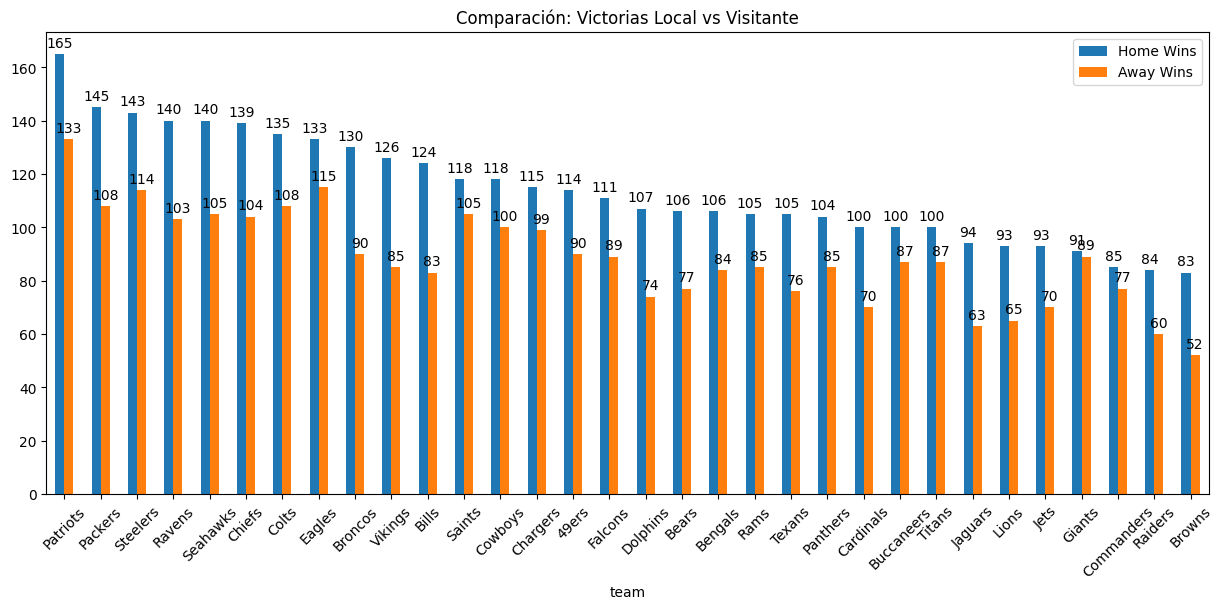

In [30]:
#Grafica de comparacion de victorias como local vs visitante

comparison = pd.DataFrame({
    'Home Wins': home_df.groupby('team')['win'].sum(),
    'Away Wins': away_df.groupby('team')['win'].sum()
}).sort_values(by='Home Wins', ascending=False)

co = comparison.plot(kind='bar', figsize=(15,6))

plt.title("Comparación: Victorias Local vs Visitante")
plt.xticks(rotation=45)

for container in co.containers:
    co.bar_label(container, fmt='%d', padding=3)
    
plt.show()

#Ya con este grafico se puede visualizar las comparaciones y se decidio poner a los 32 equipos para ver sus tops generales, algunos de los equipos aqui como Broncos, Vikings y Bills se puede ver que tienen compliaciones para jugar como visitante, por ello sus victorias como local y de visitante tienen diferencia de 40 o mas.

In [31]:
#Comparacion de equipo por año

year = 2025

df_year = teams_df[teams_df['season'] == year]

# Agrupar victorias por equipo en ese año
wins_year = df_year.groupby('team')['win'].sum().sort_values(ascending=False)

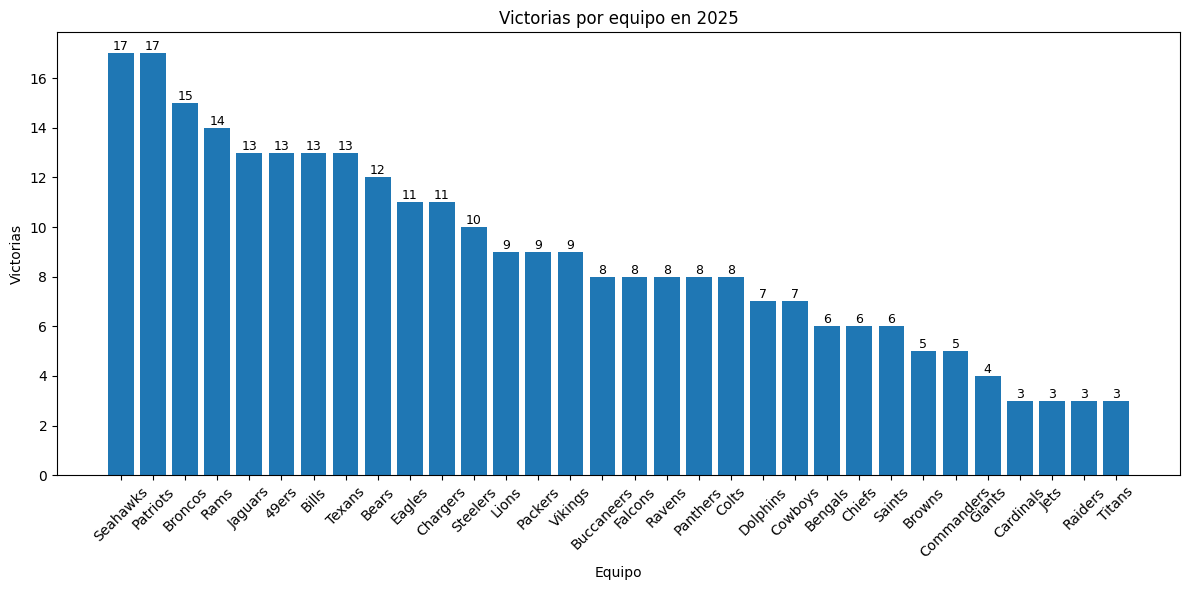

In [32]:
#Grafica de comparacion por año

plt.figure(figsize=(12,6))
bars = plt.bar(wins_year.index, wins_year.values)

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

plt.title(f"Victorias por equipo en {year}")
plt.xlabel("Equipo")
plt.ylabel("Victorias")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#En esta ultima tabla solo se ajusta el año que se requiera ver, en este ejemplo se tomo el año 2025 para comprarab la temporada mas reciente donde los Seahawks fueron los campeones de superbowl

In [33]:
#Comparar local vs visitante por año

home_year = home_df[home_df['season'] == year].groupby('team')['win'].sum()
away_year = away_df[away_df['season'] == year].groupby('team')['win'].sum()

comparison = pd.DataFrame({
    'Local': home_year,
    'Visitante': away_year
}).fillna(0)


comparison = comparison.sort_values(by='Local', ascending=False)

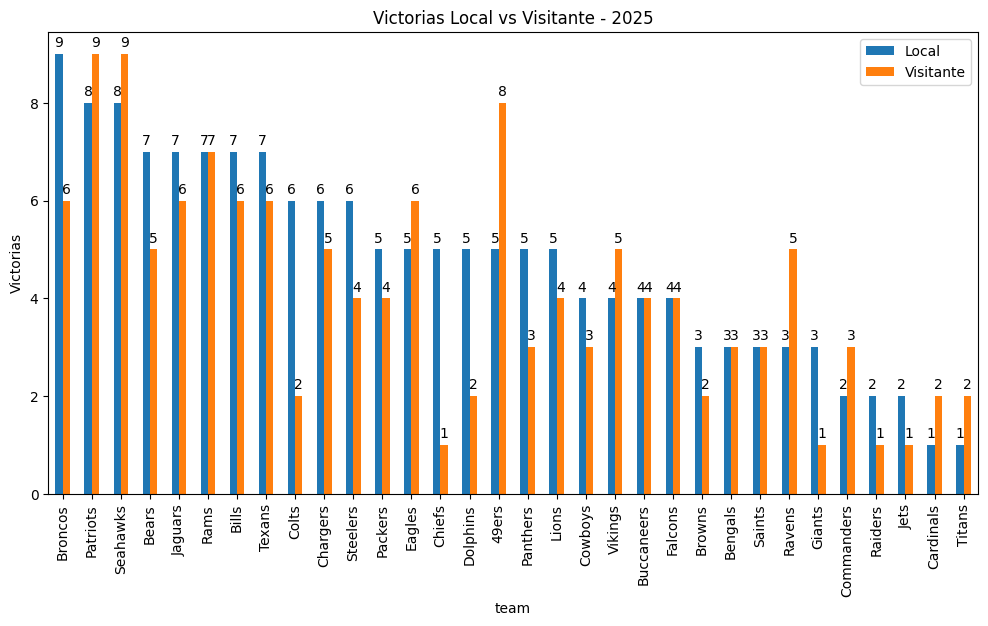

In [34]:
#Grafica de comparacion local vs visitante por año

cp = comparison.plot(kind='bar', figsize=(12,6))

plt.title(f"Victorias Local vs Visitante - {year}")
plt.xticks(rotation=90)
plt.ylabel("Victorias")

for container in cp.containers:
    cp.bar_label(container, fmt='%d', padding=3)
    

plt.show()

#Con esta grafica podemos comparar las victorias de cada equipo dentro de local como vivitante, destacan algunos ejempls como los 49ers y Ravens que tienen mas victorias de visitante que como local, o bien los Chiefs y Colts que tienen mas victorias en casa

In [35]:
#Creacion de datasets de equipo por temporada

team_season = teams_df.groupby(['season', 'team'])['win'].agg(
    wins='sum',
    games='count'
).reset_index()

team_season['win_pct'] = team_season['wins'] / team_season['games']

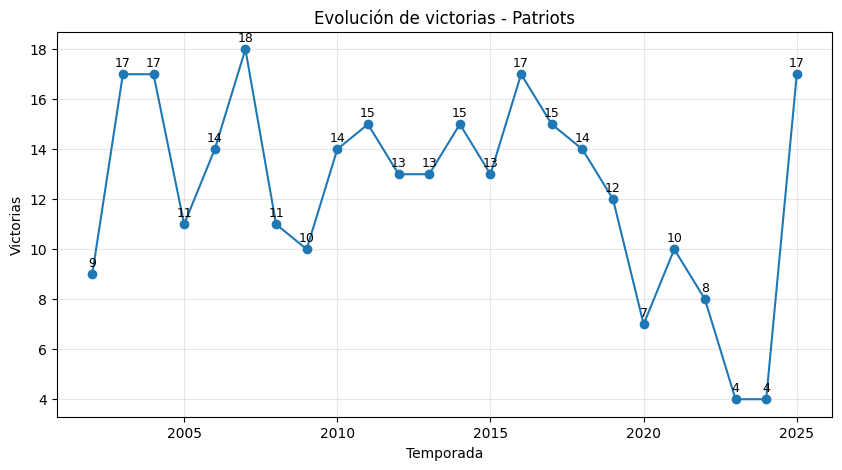

In [36]:
#Grafica de evolucion de victorias por equipo a lo largo de las temporadas

team_name = "Patriots"  # cambia el equipo

team_trend = team_season[team_season['team'] == team_name]

plt.figure(figsize=(10,5))

plt.plot(team_trend['season'], team_trend['wins'], marker='o')

plt.title(f"Evolución de victorias - {team_name}")
plt.xlabel("Temporada")
plt.ylabel("Victorias")
plt.grid(alpha=0.3)

# Agregar etiquetas numéricas en cada punto
for i, (season, wins) in enumerate(zip(team_trend['season'], team_trend['wins'])):
    plt.text(season, wins + 0.3, str(int(wins)), ha='center', fontsize=9)

plt.show()

#En este grafico se utiliza al equipo de Patriots como ejemplo, se puede ver que a lo largo de las tempodaras a tenido numeros muy altos de victorias, salvo en los años 2023 y 2024. Para cada equipo se puede visualizar. 

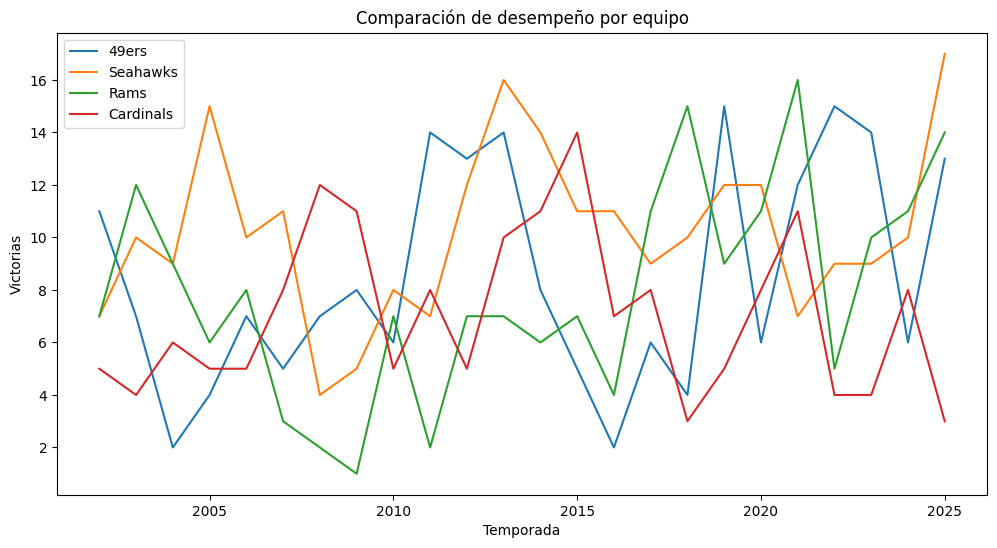

In [37]:
teams = [
    '49ers',
    'Seahawks',
    'Rams',
    'Cardinals' 
]

plt.figure(figsize=(12,6))

for t in teams:
    subset = team_season[team_season['team'] == t]
    plt.plot(subset['season'], subset['wins'], label=t)

plt.legend()
plt.title("Comparación de desempeño por equipo")
plt.xlabel("Temporada")
plt.ylabel("Victorias")

plt.show()

#Aqui ya se seleccionan los equipos, en este caso se tomaron los equipos de la NFC Oeste, esto con el fin el desempeño que han tenido a lo largo de los años (respecto a victorias) dentro del lapso establecido, aqui a destacar es quue Cardinals a sido un equipo que normalmente se mantiene abajo a comparacion de la tasa de victorias que poseen los otros miembros del grupo

In [38]:
#Importar tablas de victorias a CVS
team_season.to_csv("team_season.csv", index=False)

In [39]:
#Importar a CVS las victorias como local y visitante
home_df['type'] = 'Home'
away_df['type'] = 'Away'

combined = pd.concat([home_df, away_df])
combined.to_csv("home_away.csv", index=False)

In [40]:
# Generacion de grafica para Power BI

# Creacion de columnas de equipos ganadores de local y visitante
df['home_win'] = (df['score_home'] > df['score_away']).astype(int)

df['away_win'] = (df['score_away'] > df['score_home']).astype(int)


In [41]:
# Creacion de columnas de diferencia de puntos para local y visitante

df['point_diff_home'] = df['score_home'] - df['score_away']

df['point_diff_away'] = df['score_away'] - df['score_home']

In [42]:
# Creacion de dataset para estadisticas de local

home_stats = df.copy()

home_stats['team'] = home_stats['home']
home_stats['opponent'] = home_stats['away']

home_stats['points_scored_team'] = home_stats['score_home']
home_stats['points_allowed_team'] = home_stats['score_away']

home_stats['win'] = home_stats['home_win']

home_stats['point_diff'] = (
    home_stats['score_home'] -
    home_stats['score_away']
)

home_stats['game_type'] = 'Home'

In [43]:
# Creacion de dataset para estadisticas de visitante

away_stats = df.copy()

away_stats['team'] = away_stats['away']
away_stats['opponent'] = away_stats['home']

away_stats['points_scored_team'] = away_stats['score_away']
away_stats['points_allowed_team'] = away_stats['score_home']

away_stats['win'] = away_stats['away_win']

away_stats['point_diff'] = (
    away_stats['score_away'] -
    away_stats['score_home']
)

away_stats['game_type'] = 'Away'

In [44]:
# Union de ambos datasets para Power BI

team_games = pd.concat([home_stats, away_stats])

In [45]:
# Victorias por año

season_wins = team_games.groupby(
    ['season', 'team']
)['win'].sum().reset_index()

season_wins.columns = [
    'season',
    'team',
    'team_wins_season'
]

total_wins = team_games.groupby(
    'team'
)['win'].sum().reset_index()

total_wins.columns = [
    'team',
    'team_total_wins'
]

In [46]:
# Integrar al dataset principal

team_games = team_games.merge(
    season_wins,
    on=['season', 'team'],
    how='left'
)

team_games = team_games.merge(
    total_wins,
    on='team',
    how='left'
)

In [47]:
# Evolucion de los equipos

team_games.groupby(['season', 'team'])['win'].sum()

season  team    
2002    49ers       11
        Bears        4
        Bengals      2
        Bills        8
        Broncos      9
                    ..
2025    Seahawks    17
        Steelers    10
        Texans      13
        Titans       3
        Vikings      9
Name: win, Length: 768, dtype: int64

In [50]:
# Conversion de tiempo de posesion a minutos

team_games['possession_away_time'] = pd.to_timedelta(
    '00:' + team_games['possession_away']
)

team_games['possession_home_time'] = pd.to_timedelta(
    '00:' + team_games ['possession_home']
)

team_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 12998 entries, 0 to 12997
Data columns (total 79 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   season                         12998 non-null  int64          
 1   week                           12998 non-null  str            
 2   date                           12998 non-null  datetime64[us] 
 3   time_et                        12998 non-null  str            
 4   neutral                        12998 non-null  bool           
 5   away                           12998 non-null  str            
 6   home                           12998 non-null  str            
 7   score_away                     12998 non-null  int64          
 8   score_home                     12998 non-null  int64          
 9   first_downs_away               12998 non-null  int64          
 10  first_downs_home               12998 non-null  int64          
 11  first_downs_f

In [51]:
team_games.to_csv(
    "nfl_team_games_complete.csv",
    index=False
)